In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style('whitegrid')
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Carregar os datasets CSV da pasta 'data'
customers = pd.read_csv('../data/olist_customers_dataset.csv')
geolocation = pd.read_csv('../data/olist_geolocation_dataset.csv')
order_items = pd.read_csv('../data/olist_order_items_dataset.csv')
order_payments = pd.read_csv('../data/olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('../data/olist_order_reviews_dataset.csv')
orders = pd.read_csv('../data/olist_orders_dataset.csv')
products = pd.read_csv('../data/olist_products_dataset.csv')
sellers = pd.read_csv('../data/olist_sellers_dataset.csv')
product_translation = pd.read_csv('../data/product_category_name_translation.csv')

In [3]:
data = {
    "customers" : customers,
    "geolocation" : geolocation,
    "order_items" : order_items,
    "order_payments" : order_payments,
    "order_reviews" : order_reviews,
    "orders" : orders,
    "products" : products,
    "sellers" : sellers,
    "product_translation" : product_translation
}

In [4]:
for c, v in data.items():
    print(c, v.shape)

customers (99441, 5)
geolocation (1000163, 5)
order_items (112650, 7)
order_payments (103886, 5)
order_reviews (99224, 7)
orders (99441, 8)
products (32951, 9)
sellers (3095, 4)
product_translation (71, 2)


In [5]:
for c, v in data.items():
    print(c, v.isnull().sum().sum())

customers 0
geolocation 0
order_items 0
order_payments 0
order_reviews 145903
orders 4908
products 2448
sellers 0
product_translation 0


In [6]:
# Não será preciso retirar as duplicatas da geolocation, visto que o mesmo CEP pode abranger
# diferentes lat/lng. É bem comum, pois o CEP representa uma região, não um ponto exato.
for c, v in data.items():
    print(c, v.duplicated().sum().sum())

customers 0
geolocation 261831
order_items 0
order_payments 0
order_reviews 0
orders 0
products 0
sellers 0
product_translation 0


In [7]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [8]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [9]:
#Não será preciso realizar a tratativa desses dados, ou seja, não precisa retirar os valores nulos.
order_reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [10]:
order_reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13


In [11]:
order_reviews["review_score"].value_counts().sort_values(ascending=False)

review_score
5    57328
4    19142
1    11424
3     8179
2     3151
Name: count, dtype: int64

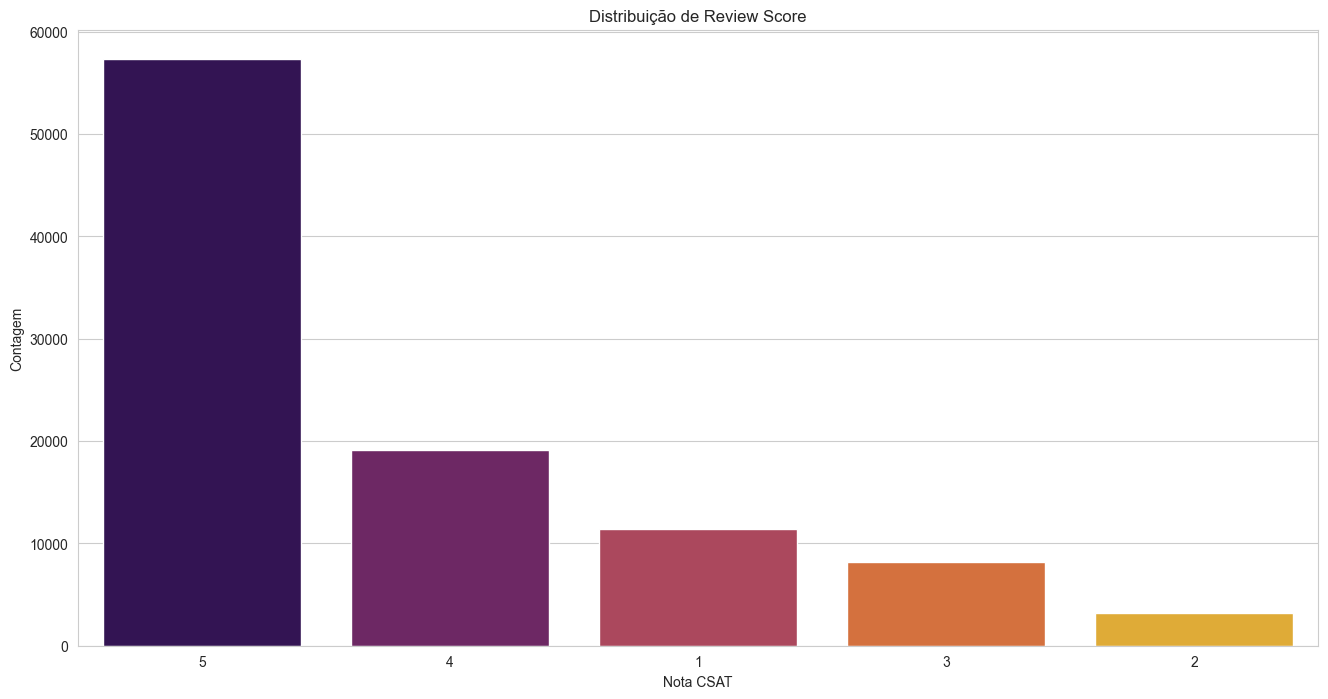

In [49]:
plt.figure(figsize=(16, 8))
sns.countplot(data=order_reviews, x="review_score", order=order_reviews["review_score"].value_counts().index, palette='inferno')
plt.title("Distribuição de Review Score")
plt.xlabel("Nota CSAT")
plt.ylabel("Contagem")
plt.show()

In [13]:
def csat(nota):
    if nota == 1:
        return "Extremamente insatisfeito"
    elif nota == 2:
        return "Insatisfeito"
    elif nota == 3:
        return "Indiferente"
    elif nota == 4:
        return "Satisfeito"
    else:
        return "Extremanete satisfeito"

In [14]:
order_reviews['CSAT'] = order_reviews['review_score'].apply(csat)

In [15]:
order_reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,CSAT
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59,Satisfeito
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13,Extremanete satisfeito
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24,Extremanete satisfeito
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06,Extremanete satisfeito
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53,Extremanete satisfeito
...,...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30,Extremanete satisfeito
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42,Extremanete satisfeito
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43,Extremanete satisfeito
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13,Satisfeito


In [16]:
ordernco = order_reviews[['review_id', 'order_id', 'review_score', 'CSAT']]

In [17]:
ordernco

,review_id,order_id,review_score,CSAT
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,Satisfeito
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,Extremanete satisfeito
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,Extremanete satisfeito
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,Extremanete satisfeito
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,Extremanete satisfeito
...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,Extremanete satisfeito
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,Extremanete satisfeito
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,Extremanete satisfeito
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,Satisfeito


In [ ]:
def classify(df):
    red = df[df['review_score'] <= 2]
    yellow = df[df['review_score'] == 3]
    green = df[df['review_score'] > 4]
    return red, yellow, green

In [27]:
red, yellow, green = classify(order_reviews)

In [29]:
red

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,CSAT
5,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,NaN,NaN,2018-04-13 00:00:00,2018-04-16 00:39:37,Extremamente insatisfeito
16,9314d6f9799f5bfba510cc7bcd468c01,0dacf04c5ad59fd5a0cc1faa07c34e39,2,NaN,"GOSTARIA DE SABER O QUE HOUVE, SEMPRE RECEBI E...",2018-01-18 00:00:00,2018-01-20 21:25:45,Insatisfeito
19,373cbeecea8286a2b66c97b1b157ec46,583174fbe37d3d5f0d6661be3aad1786,1,Não chegou meu produto,Péssimo,2018-08-15 00:00:00,2018-08-15 04:10:37,Extremamente insatisfeito
29,2c5e27fc178bde7ac173c9c62c31b070,0ce9a24111d850192a933fcaab6fbad3,1,NaN,Não gostei ! Comprei gato por lebre,2017-12-13 00:00:00,2017-12-16 07:14:07,Extremamente insatisfeito
32,58044bca115705a48fe0e00a21390c54,68e55ca79d04a79f20d4bfc0146f4b66,1,NaN,Sempre compro pela Internet e a entrega ocorre...,2018-04-08 00:00:00,2018-04-09 12:22:39,Extremamente insatisfeito
...,...,...,...,...,...,...,...,...
99174,cf0b8c06ba024a8a8d3f2ac51fcd99f4,fff2cdc825f9fc0ba3c04227cfa02303,2,NaN,NaN,2018-03-09 00:00:00,2018-04-23 17:52:49,Insatisfeito
99184,6cf47345d15e054dd6df872e929bdb27,54e6829fe81bc86cf88b12e6d07ea298,1,NaN,NaN,2017-06-08 00:00:00,2017-06-08 22:52:39,Extremamente insatisfeito
99200,2ee221b28e5b6fceffac59487ed39348,f2d12dd37eaef72ed7b1186b2edefbcd,2,Foto enganosa,Foto muito diferente principalmente a graninha...,2018-03-28 00:00:00,2018-05-25 01:23:26,Insatisfeito
99203,5085bc489aa6b58a29c4f922d59ff826,18ed848509774f56cc8c1c0a1903ad7f,2,NaN,Tive um problema na entrega em que o correio c...,2018-02-21 00:00:00,2018-02-23 11:43:12,Insatisfeito


In [32]:
textminingredtitle = red.dropna(subset=['review_comment_title'])

In [33]:
textminingredtitle

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,CSAT
19,373cbeecea8286a2b66c97b1b157ec46,583174fbe37d3d5f0d6661be3aad1786,1,Não chegou meu produto,Péssimo,2018-08-15 00:00:00,2018-08-15 04:10:37,Extremamente insatisfeito
167,5f938e5f5f2e9a75710b54feeb9ea610,d9ff0185a300435402f043124f530274,1,Médio,A peça não serviu,2018-05-11 00:00:00,2018-05-14 14:08:04,Extremamente insatisfeito
190,c40a6b6e0181e5ec0d12cbc2e12c49d3,f3468d6a2c7586711e9952242898aad4,1,falta de produto e quebra,Faltou 1 produto e os que recebi 1 veio quebrado,2018-05-23 00:00:00,2018-05-23 22:23:00,Extremamente insatisfeito
197,06f47dacd0575e592bf6a17e922ce6cd,82348f1b5f24ac795fa9320e02c49553,1,não recebi ainda,aqui está descrevendo como entregue só que ate...,2018-06-28 00:00:00,2018-06-29 16:34:46,Extremamente insatisfeito
276,f7eb8792e67d53e01a224bfa9b6802b2,a0f2f8b0523207a13f02225bc812ed23,1,Horrível,Cancelaram a minha compra um dia antes da entr...,2018-08-05 00:00:00,2018-08-05 09:27:55,Extremamente insatisfeito
...,...,...,...,...,...,...,...,...
98966,52baca75dbcbb53c69ae3e39e4632675,e38ff07f7864e8fd4fd51687cba79d89,2,Médio,NaN,2018-07-25 00:00:00,2018-07-28 03:09:47,Insatisfeito
99055,5dcc936952f7e67f7faa64c8f57e97a9,719a2a4825d52ce82cbc8698a71495ba,1,produto não entregue,"o produto não foi entregue, a empresa não se p...",2018-05-24 00:00:00,2018-05-26 05:11:57,Extremamente insatisfeito
99086,7b85c6acaddb354af9aa840528838d9f,33a3edb84b9df4cb49546859b990ac6d,1,Empres não confiável,Minha opinião é que se comprei o produto ele t...,2018-03-21 00:00:00,2018-10-11 13:34:54,Extremamente insatisfeito
99117,61249dd0992d25082ab94464a2a47668,2437dfd68fb453ad27e1898c8b1fe868,2,Rápido porém não bom,Eu recebi o produto no prazo porém já veio lig...,2018-07-28 00:00:00,2018-07-29 02:14:59,Insatisfeito


In [34]:
textminingredcomment = red.dropna(subset=['review_comment_message'])

In [35]:
textminingredcomment

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,CSAT
16,9314d6f9799f5bfba510cc7bcd468c01,0dacf04c5ad59fd5a0cc1faa07c34e39,2,NaN,"GOSTARIA DE SABER O QUE HOUVE, SEMPRE RECEBI E...",2018-01-18 00:00:00,2018-01-20 21:25:45,Insatisfeito
19,373cbeecea8286a2b66c97b1b157ec46,583174fbe37d3d5f0d6661be3aad1786,1,Não chegou meu produto,Péssimo,2018-08-15 00:00:00,2018-08-15 04:10:37,Extremamente insatisfeito
29,2c5e27fc178bde7ac173c9c62c31b070,0ce9a24111d850192a933fcaab6fbad3,1,NaN,Não gostei ! Comprei gato por lebre,2017-12-13 00:00:00,2017-12-16 07:14:07,Extremamente insatisfeito
32,58044bca115705a48fe0e00a21390c54,68e55ca79d04a79f20d4bfc0146f4b66,1,NaN,Sempre compro pela Internet e a entrega ocorre...,2018-04-08 00:00:00,2018-04-09 12:22:39,Extremamente insatisfeito
39,9fd59cd04b42f600df9f25e54082a8d1,3c314f50bc654f3c4e317b055681dff9,1,NaN,Nada de chegar o meu pedido.,2017-04-21 00:00:00,2017-04-23 05:37:03,Extremamente insatisfeito
...,...,...,...,...,...,...,...,...
99155,2fc8295a24978092328d3a329d22940e,e809c167a9cfd31aee1293abe8995065,1,NaN,Eu recebi o seguinte email e preciso saber com...,2018-02-09 00:00:00,2018-02-13 13:03:24,Extremamente insatisfeito
99169,3450ec3bbabeb09a08b00fc72da87a30,c46f950813dd2dd9bab4188dceb83175,1,NaN,Boa tarde. \r\nNão recebo todos os produtos fa...,2017-12-08 00:00:00,2017-12-08 19:07:00,Extremamente insatisfeito
99200,2ee221b28e5b6fceffac59487ed39348,f2d12dd37eaef72ed7b1186b2edefbcd,2,Foto enganosa,Foto muito diferente principalmente a graninha...,2018-03-28 00:00:00,2018-05-25 01:23:26,Insatisfeito
99203,5085bc489aa6b58a29c4f922d59ff826,18ed848509774f56cc8c1c0a1903ad7f,2,NaN,Tive um problema na entrega em que o correio c...,2018-02-21 00:00:00,2018-02-23 11:43:12,Insatisfeito


In [47]:
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('portuguese'))
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\vitor\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\vitor\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [39]:
# Função de pré-processamento: tokenizar, lowercase, remover stopwords e não-alfabéticos
def preprocess_text(text):
    tokens = nltk.word_tokenize(text.lower())
    filtered_tokens = []
    for word in tokens:
        if word.isalpha() and word not in stop_words:
            filtered_tokens.append(word)
    return filtered_tokens

Top 20 palavras mais frequentes:
[('produto', 6171), ('recebi', 3265), ('comprei', 1873), ('veio', 1549), ('entrega', 1406), ('ainda', 1397), ('entregue', 1323), ('chegou', 1174), ('nao', 939), ('prazo', 908), ('compra', 902), ('pedido', 788), ('loja', 771), ('dia', 761), ('agora', 687), ('apenas', 540), ('pois', 523), ('nada', 513), ('produtos', 513), ('site', 508)]


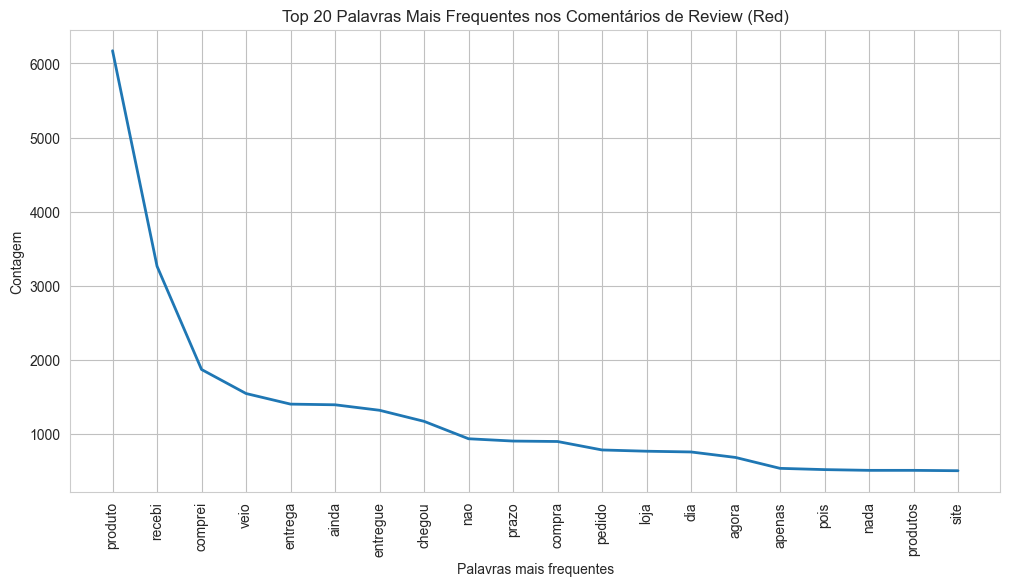

In [46]:
textminingredcomment['tokens_message'] = textminingredcomment['review_comment_message'].apply(preprocess_text)

all_tokens = []
for sublist in textminingredcomment['tokens_message']:
    for token in sublist:
        all_tokens.append(token)

# Calcular frequência das palavras
freq_dist = nltk.FreqDist(all_tokens)

# Exibir top 20 palavras mais frequentes
print("Top 20 palavras mais frequentes:")
print(freq_dist.most_common(20))

# Plotar distribuição com Matplotlib
plt.figure(figsize=(12, 6))
freq_dist.plot(20, title="Top 20 Palavras Mais Frequentes nos Comentários de Review (Red)")
plt.xlabel('Palavras mais frequentes')
plt.ylabel('Contagem')
plt.show()

Top 20 palavras mais frequentes:
[('produto', 637), ('recebi', 225), ('recomendo', 186), ('entrega', 147), ('entregue', 108), ('nao', 99), ('ruim', 95), ('errado', 91), ('defeito', 66), ('péssimo', 64), ('veio', 64), ('chegou', 61), ('pedido', 50), ('ainda', 47), ('péssima', 43), ('falta', 40), ('faltando', 40), ('atraso', 36), ('diferente', 34), ('incompleto', 33)]


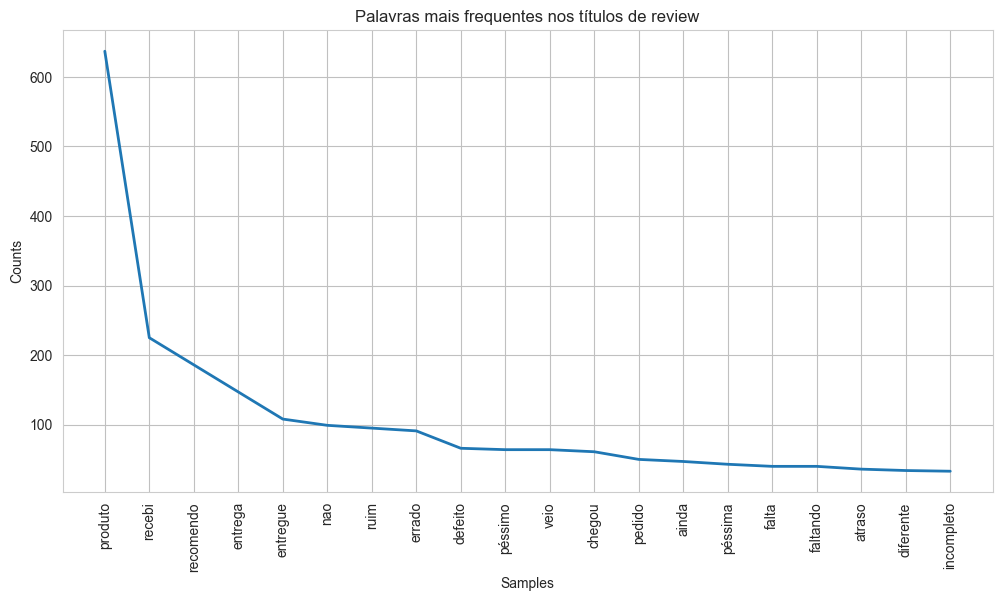

In [ ]:
textminingredtitle['tokens_title'] = textminingredtitle['review_comment_title'].apply(preprocess_text)

all_tokens = []
for sublist in textminingredtitle['tokens_title']:
    for token in sublist:
        all_tokens.append(token)

# Calcular frequência das palavras
freq_dist = nltk.FreqDist(all_tokens)

# Exibir top 20 palavras mais frequentes
print("Top 20 palavras mais frequentes:")
print(freq_dist.most_common(20))

# Plotar distribuição
plt.figure(figsize=(12, 6))
freq_dist.plot(20, title="Top 20 Palavras Mais Frequentes nos Títulos de Review (Red)")
plt.xlabel('Palavras mais frequentes')
plt.ylabel('Contagem')
plt.show()